# Generating Initial Populations

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt

## Sequences

Below are some examples of how sequences can be generated using popular random number generation tools.

### Pseudo-random sampling

In [2]:
# Generate 200 "random" numbers
np.random.seed(42)
N=200 # number of samples
P_random_pseudo=np.random.rand(N,N) 

This method is "pseudo"-random as it is actually completely deterministic, if you know some key information. Both `random.random` and `numpy.random` use the [Mersenne Twister](https://en.wikipedia.org/wiki/Mersenne_Twister). Because new values are generated using a list of old values, sufficient observations of "random" data allows prediction of future values. Also, the same "random" values can be generated simply by using the same seed.

### Generalized Halton Number Generator

In [3]:
# Sampling using Generalized Halton Number Quasi-random Generator
# pip install scipy
import numpy as np
from scipy.stats import qmc

# Generate an N x 7 Halton sequence
sampler = qmc.Halton(d=7, scramble=False)
P_random_quasi = sampler.random(n=N)

In [4]:
P_random_quasi

array([[0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.5       , 0.33333333, 0.2       , ..., 0.09090909, 0.07692308,
        0.05882353],
       [0.25      , 0.66666667, 0.4       , ..., 0.18181818, 0.15384615,
        0.11764706],
       ...,
       [0.63671875, 0.90946502, 0.5776    , ..., 0.959429  , 0.16613564,
        0.62629758],
       [0.38671875, 0.05761317, 0.7776    , ..., 0.05860255, 0.24305872,
        0.68512111],
       [0.88671875, 0.3909465 , 0.9776    , ..., 0.14951165, 0.31998179,
        0.74394464]], shape=(200, 7))

As is evident in the summary graph at the end of this page, the [Halton sequence](https://en.wikipedia.org/wiki/Halton_sequence) has many disadvantages. Depending on the input parameters, results could show overt correlation, or at least uneven sampling. In this example, we can see some obvious diagonal bands forming, as well as patterns of blank space.

### Box-Muller Transform

$BM_x = \sqrt(-2ln(u1)) \times cos(2 \pi u2)$

$BM_x = \sqrt(-2ln(u1)) \times sin(2 \pi u2)$


In [5]:
# Generate uniformly distributed values between 0 and 1
u1 = np.random.uniform(size=(N))
u2 = np.random.uniform(size=(N))

# Calculaute x and y values using Box-Muller
P_BM_x = np.sqrt(-2*np.log(u1))*np.cos(2*math.pi*u2)
P_BM_y = np.sqrt(-2*np.log(u1))*np.sin(2*math.pi*u2)

One of the drawbacks of the [Box-Muller transform](https://en.wikipedia.org/wiki/Box%E2%80%93Muller_transform) is the tendency for values to cluster around the mean. This has to do with 32-bit integers and how numbers are represented by processors. Additionally, calculating the square root (step 4) can be costly.

### Central Limit Theorem

In [6]:
# Sampling using the Central Limit Theorem
import random

P_CLT_x=[2.0 * math.sqrt(N) * (sum(random.randint(0,1) for x in range(N)) / N - 0.5) for x in range(N)]
P_CLT_y=[2.0 * math.sqrt(N) * (sum(random.randint(0,1) for x in range(N)) / N - 0.5) for x in range(N)]

### Sobol Sequence

In [7]:
# Sobol low-discrepancy-sequence (LDS)
# !pip install sobol_seq
import sobol_seq
P_sobel=sobol_seq.i4_sobol_generate(2,N)

### Latin Hypercube Sampling

In [8]:
import numpy as np
from scipy.stats import qmc

# Latin Hypercube sampling
sampler = qmc.LatinHypercube(d=2, scramble=False)
P_LHS = sampler.random(n=N)

In [9]:
P_LHS 

array([[0.9925, 0.2725],
       [0.6425, 0.6875],
       [0.1175, 0.2775],
       [0.0275, 0.3725],
       [0.9525, 0.3225],
       [0.3875, 0.1575],
       [0.2525, 0.8125],
       [0.8275, 0.7175],
       [0.3925, 0.5275],
       [0.5125, 0.4825],
       [0.6925, 0.2975],
       [0.2425, 0.7525],
       [0.4725, 0.4375],
       [0.6075, 0.7275],
       [0.6675, 0.0375],
       [0.1525, 0.7925],
       [0.9125, 0.9825],
       [0.7325, 0.9125],
       [0.2925, 0.6975],
       [0.5925, 0.7325],
       [0.2575, 0.9375],
       [0.3425, 0.2525],
       [0.1375, 0.6175],
       [0.3125, 0.3425],
       [0.4675, 0.7575],
       [0.6725, 0.5925],
       [0.4475, 0.3275],
       [0.5025, 0.4675],
       [0.5625, 0.6625],
       [0.7075, 0.5325],
       [0.1675, 0.2325],
       [0.7475, 0.1175],
       [0.1575, 0.4325],
       [0.5475, 0.1075],
       [0.4925, 0.9175],
       [0.6175, 0.9725],
       [0.3225, 0.8225],
       [0.0725, 0.0125],
       [0.1625, 0.4125],
       [0.3325, 0.5875],


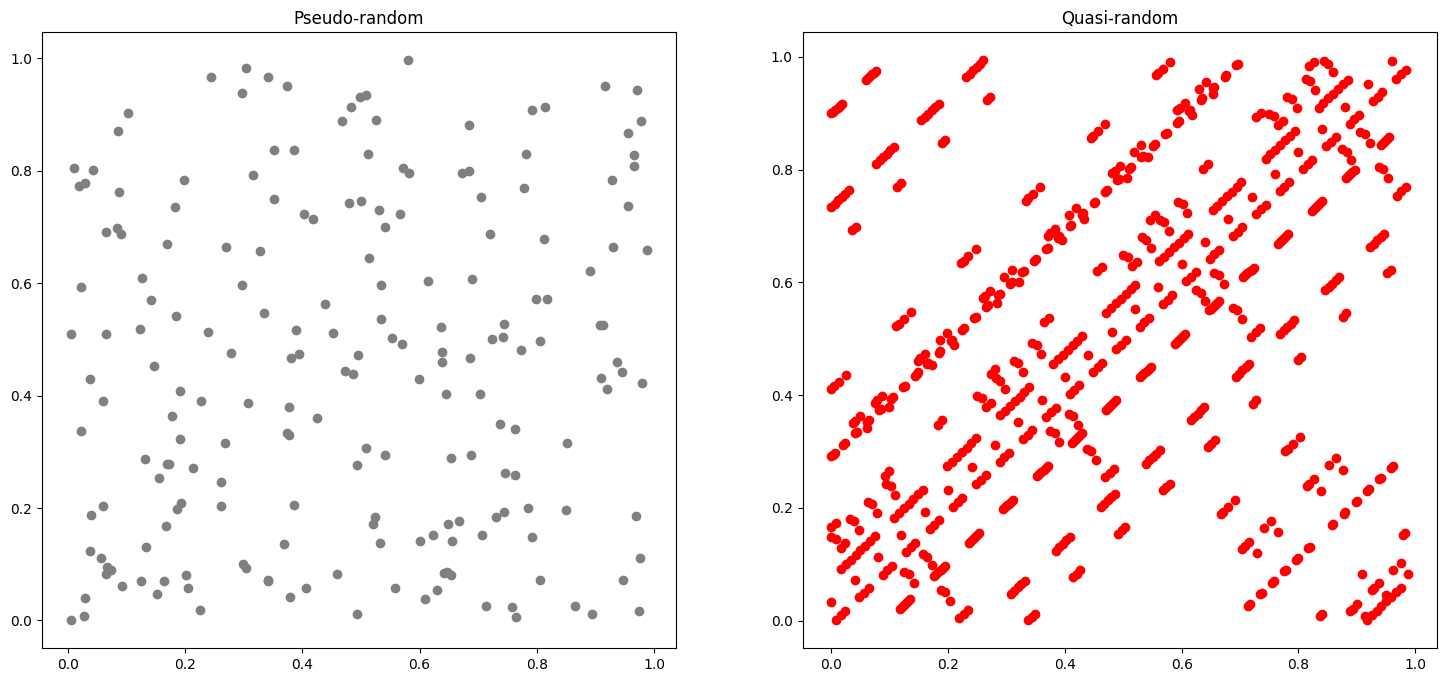

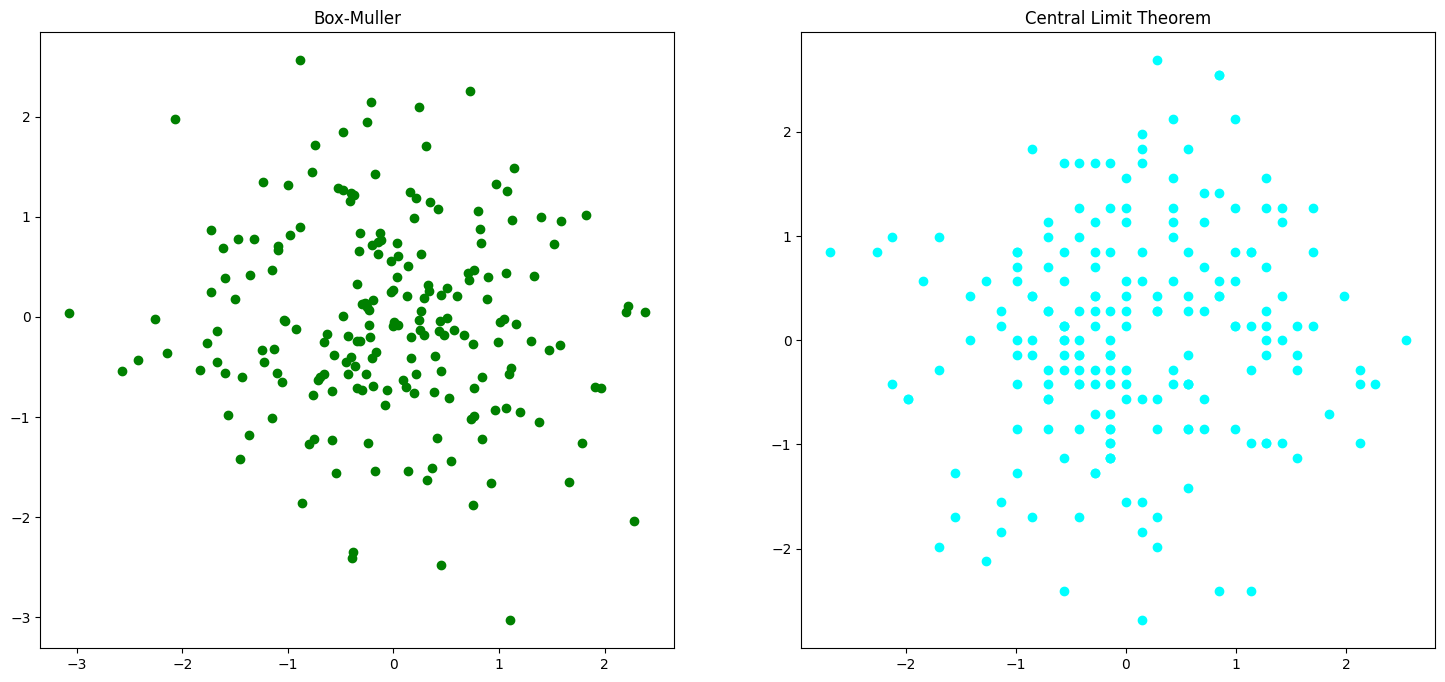

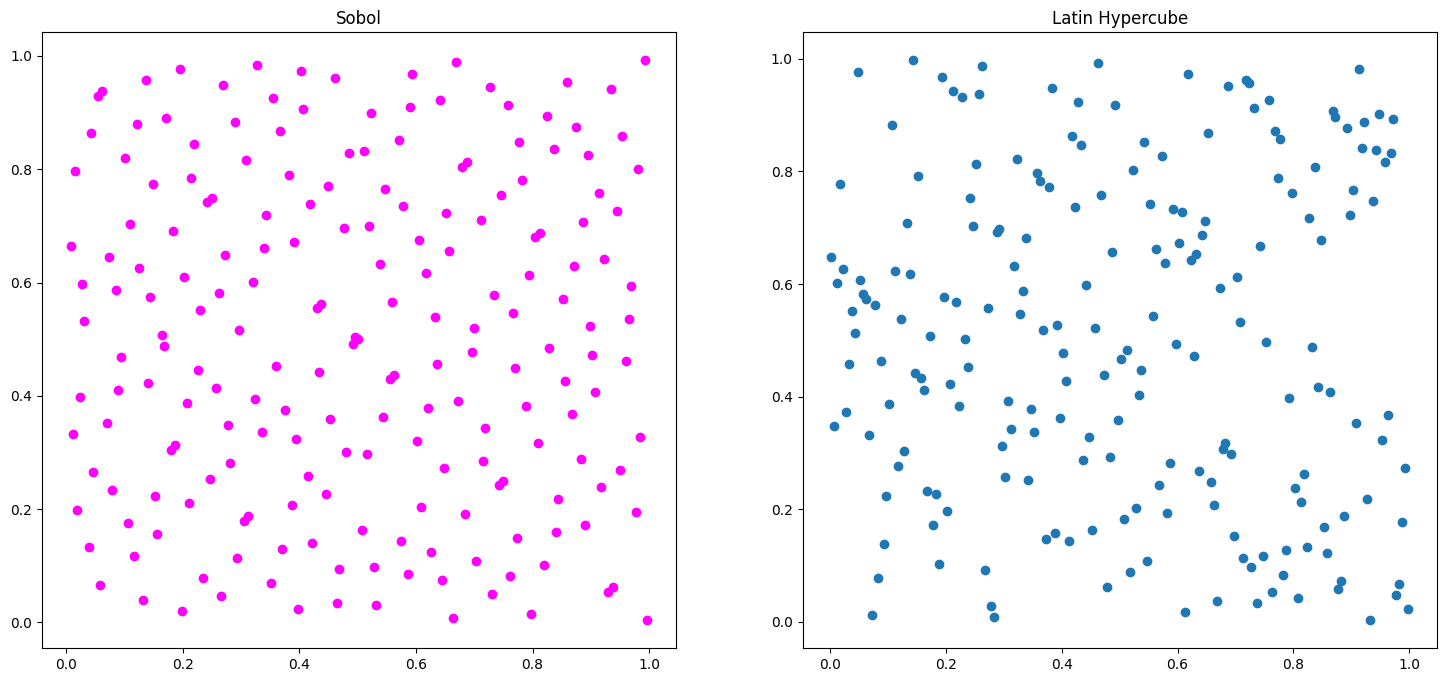

In [10]:
f, (ax1, ax2) = plt.subplots(ncols=2, figsize=(18,8))
f, (ax3,ax4) = plt.subplots(ncols=2, figsize=(18,8))
f, (ax5, ax6) = plt.subplots(ncols=2, figsize=(18,8))
ax1.scatter(P_random_pseudo[:,0], P_random_pseudo[:,1], color="gray")
ax2.scatter(P_random_quasi[:100], P_random_quasi[100:], color="red")
ax3.scatter(P_BM_x, P_BM_y, color="green")
ax4.scatter(P_CLT_x, P_CLT_y, color="cyan")
ax5.scatter(P_sobel[:,0], P_sobel[:,1], color="magenta")
ax6.plot(P_LHS[:,0], P_LHS[:,1], "o")
                          
ax1.set_title("Pseudo-random")
ax2.set_title("Quasi-random")
ax3.set_title("Box-Muller")
ax4.set_title("Central Limit Theorem")
ax5.set_title("Sobol")
ax6.set_title("Latin Hypercube")
plt.show()
# plt.savefig('CH07_F02.png', format='png', dpi=300)

## Sampling in Pymoo

Pymoo provide different sampling methods to create an initial population or an initial search point.  Examples include random sampling and Latin Hypercube sampling.

### Random Sampling

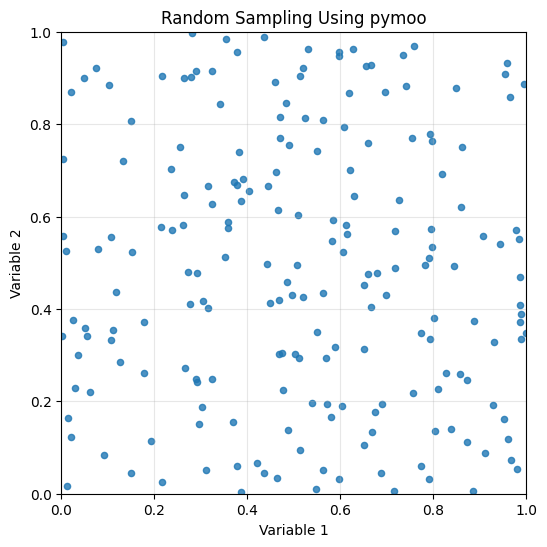

In [11]:
#!pip install -U pymoo
import matplotlib.pyplot as plt
from pymoo.core.problem import Problem
from pymoo.operators.sampling.rnd import FloatRandomSampling

problem = Problem(
    n_var=2,
    n_obj=1,
    n_constr=0,
    xl=0,
    xu=1
)

sampling = FloatRandomSampling()

# Generate 200 random samples
X = sampling.do(problem, 200).get("X")

# Plot the samples
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.8)
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Random Sampling Using pymoo")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

### Latin Hypercube Sampling

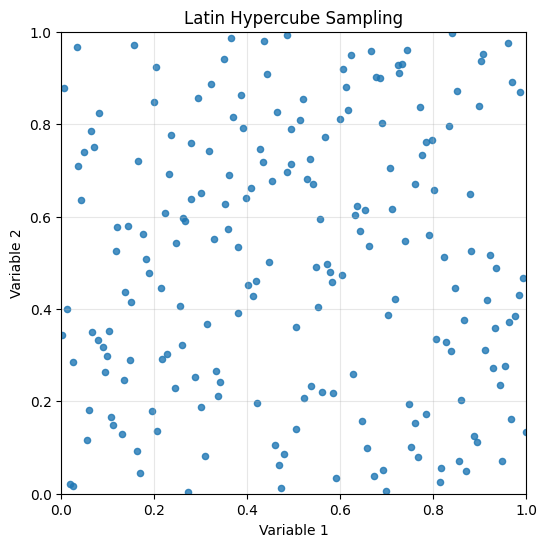

In [12]:
import matplotlib.pyplot as plt
from pymoo.operators.sampling.lhs import LHS

sampling = LHS()

# Generate 200 Latin Hypercube samples
X = sampling.do(problem, 200).get("X")

# Plot the samples
plt.figure(figsize=(6, 6))
plt.scatter(X[:, 0], X[:, 1], s=20, alpha=0.8)
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Latin Hypercube Sampling")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.show()

## Permutations

Random permutations can also be generated for existing datasets. Below are a few examples.

### `np.random.permutation`

In [13]:
# Randomly permute a sequence, or return a permuted range.
per1=np.random.permutation(10)
print(per1)

[5 8 4 0 2 1 7 6 9 3]


### `np.shuffle`

In [14]:
# Another method
per2 = np.array([5, 4, 9, 0, 1, 2, 6, 8, 7, 3])
np.random.shuffle(per2)
print(per2)

[8 3 9 2 1 4 6 5 7 0]


### Initial Population as real-value permutations

In [15]:
# Population of initial solution as real-value permuations 
pop_init = np.arange(50).reshape((10,5))
np.random.permutation(pop_init)

array([[ 5,  6,  7,  8,  9],
       [45, 46, 47, 48, 49],
       [ 0,  1,  2,  3,  4],
       [30, 31, 32, 33, 34],
       [35, 36, 37, 38, 39],
       [40, 41, 42, 43, 44],
       [20, 21, 22, 23, 24],
       [25, 26, 27, 28, 29],
       [10, 11, 12, 13, 14],
       [15, 16, 17, 18, 19]])

### Initial Population as binary permutations

In [16]:
# Population of initial solution as binary permutations 
from itertools import combinations
size=5 # number of bits in the binary string
ones=2 # number of ones in each binary string

for pos in map(set, combinations(range(size), ones)):
     print([int(i in pos) for i in range(size)], sep='\n')

[1, 1, 0, 0, 0]
[1, 0, 1, 0, 0]
[1, 0, 0, 1, 0]
[1, 0, 0, 0, 1]
[0, 1, 1, 0, 0]
[0, 1, 0, 1, 0]
[0, 1, 0, 0, 1]
[0, 0, 1, 1, 0]
[0, 0, 1, 0, 1]
[0, 0, 0, 1, 1]


## Example: Generating a random route between two points

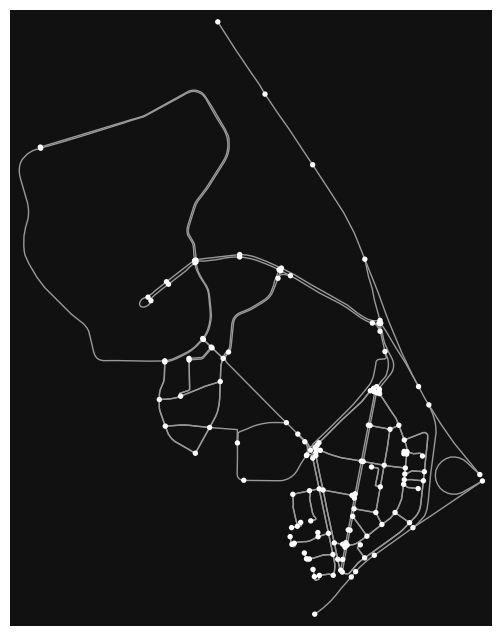

In [17]:
import osmnx as ox
import random
from collections import deque

G = ox.graph_from_place("KFUPM, Dhahran, Saudi Arabia", network_type="drive")
fig, ax = ox.plot_graph(G)

In [18]:
import random
from collections import deque

import osmnx as ox
from optalgotools.structures import Node


def randomized_search(G, source_xy, destination_xy):
    """
    source_xy and destination_xy must be (latitude, longitude).
    """

    source_lat, source_lon = source_xy
    destination_lat, destination_lon = destination_xy

    source_node = ox.distance.nearest_nodes(
        G, X=source_lon, Y=source_lat
    )

    destination_node = ox.distance.nearest_nodes(
        G, X=destination_lon, Y=destination_lat
    )

    origin = Node(graph=G, osmid=source_node)
    target = Node(graph=G, osmid=destination_node)

    frontier = [origin]
    explored = set()

    while frontier:
        node = random.choice(frontier)
        frontier.remove(node)

        explored.add(node.osmid)

        for child in node.expand():
            if child.osmid in explored:
                continue

            if any(child.osmid == n.osmid for n in frontier):
                continue

            if child.osmid == target.osmid:
                return child.path()

            frontier.append(child)

    raise ValueError(
        "The source and destination are not connected in the graph."
    )

In [19]:
import osmnx as ox

building_21 = ox.geocode(
    "Building 21, King Fahd University of Petroleum and Minerals, Dhahran, Saudi Arabia"
)

kfupm_mall = ox.geocode(
    "KFUPM Square, Dhahran, Saudi Arabia"
)

print("Building 21:", building_21)
print("KFUPM Mall:", kfupm_mall)

random_route = randomized_search(
    G,
    source_xy=building_21,
    destination_xy=kfupm_mall
)

Building 21: (26.3063924, 50.1452452)
KFUPM Mall: (26.3001373, 50.1484111)


The function above modifies a typical graph search algorithm by scrambling the frontier nodes. This means that candidates for expansion are "random", which means different routes are yielded when called repeatedly.

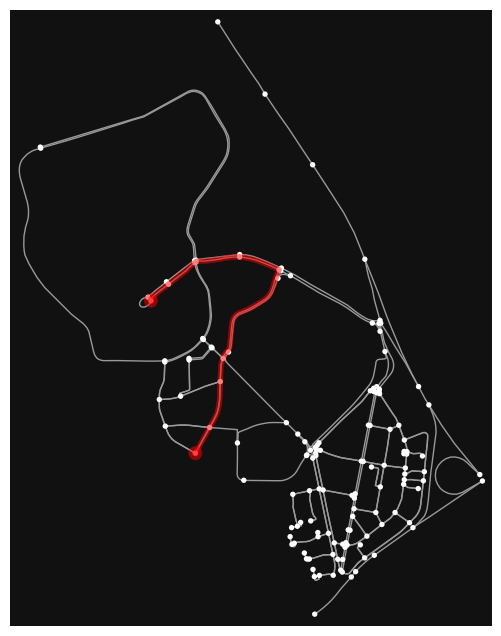

In [20]:
fig, ax = ox.plot_graph_route(G, random_route)

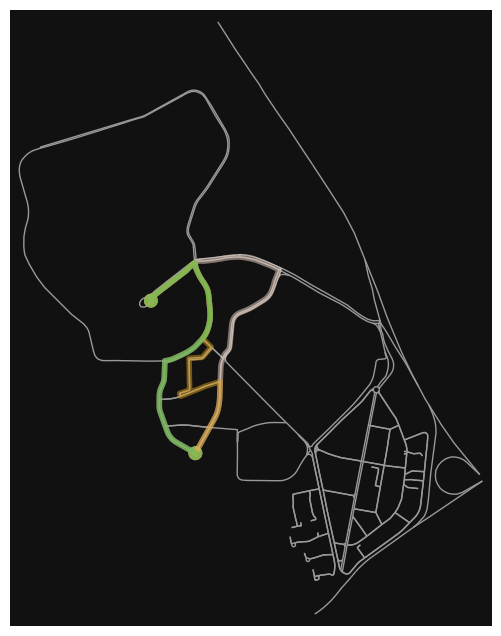

In [21]:
import random
import osmnx as ox

random_hexa = lambda: random.randint(0, 255)

# Geocode the locations
building_21 = ox.geocode(
    "Building 21, King Fahd University of Petroleum and Minerals, Dhahran, Saudi Arabia"
)

kfupm_mall = ox.geocode(
    "KFUPM Square, Dhahran, Saudi Arabia"
)

# Generate five randomized routes
routes = [
    randomized_search(
        G,
        source_xy=building_21,
        destination_xy=kfupm_mall
    )
    for _ in range(5)
]

# Generate five random colors
route_colors = [
    "#{:02X}{:02X}{:02X}".format(
        random_hexa(),
        random_hexa(),
        random_hexa()
    )
    for _ in range(5)
]

# Plot the routes
fig, ax = ox.plot_graph_routes(
    G,
    routes,
    route_colors=route_colors,
    route_linewidth=6,
    node_size=0
)